# BO baseline with a time-varying action scale

`01_bo_baseline_simple.ipynb` searches **one** scale factor per channel, held for the whole batch.
Here the batch is cut into fixed-length segments and BO searches **one factor per segment per channel**,
so the recipe can be pushed up early and pulled back late (or the reverse).

Search dimension is `n_segments * len(SCALED)`, so `SEGMENT_HOURS` trades resolution against BO budget:

| `SEGMENT_HOURS` | segments | dims (2 channels) | usable `n_calls` |
|---|---|---|---|
| 46 | 5 | 10 | ~80 |
| 23 | 10 | 20 | ~150 |
| 5 | 46 | 92 | 600+ (GP struggles) |

Default is 23 h. Set `SEGMENT_HOURS = 5.0` for a 5-hour decision interval, but raise `n_calls` a lot —
at ~6 s per simulated batch a 92-dim search is hours of compute and vanilla `gp_minimize` is weak there.

In [12]:
import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath("..")
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.dirname(ROOT))

from utils.recipe import Recipe, RecipeCombo
from utils.peni_env_setup import PenSimEnv
from utils.ode_patch import patch_fastodeint
from PenSimPy.pensimpy.data.constants import (
    FS, FOIL, FG, PRES, DISCHARGE, WATER, PAA,
    FS_DEFAULT_PROFILE, FOIL_DEFAULT_PROFILE, FG_DEFAULT_PROFILE,
    PRESS_DEFAULT_PROFILE, DISCHARGE_DEFAULT_PROFILE,
    WATER_DEFAULT_PROFILE, PAA_DEFAULT_PROFILE,
)
from skopt import gp_minimize
from skopt.space import Real

patch_fastodeint()

In [13]:
CONC_COL = "Penicillin Concentration"
PHYSICAL_P_MAX = 40.0
BATCH_HOURS = 230.0

SEGMENT_HOURS = 23.0      # length of one decision interval; 5.0 = the 5-hour version
# SCALED = [FS, FG]
SCALED = [FS]
LOW, HIGH = 0.5, 1.5

seed = 2
n_calls = 100
n_random = 10

DEFAULTS = {
    FS: FS_DEFAULT_PROFILE, FOIL: FOIL_DEFAULT_PROFILE, FG: FG_DEFAULT_PROFILE,
    PRES: PRESS_DEFAULT_PROFILE, DISCHARGE: DISCHARGE_DEFAULT_PROFILE,
    WATER: WATER_DEFAULT_PROFILE, PAA: PAA_DEFAULT_PROFILE,
}

N_SEG = int(math.ceil(BATCH_HOURS / SEGMENT_HOURS))
SEG_EDGES = [min((k + 1) * SEGMENT_HOURS, BATCH_HOURS) for k in range(N_SEG)]

print(f"{N_SEG} segments x {len(SCALED)} channels = {N_SEG * len(SCALED)} search dimensions")

10 segments x 1 channels = 10 search dimensions


In [14]:
def segment_of(t):
    """Segment a setpoint at time t belongs to.

    Recipe.get_value_at returns the *right* setpoint, so the setpoint at time t
    governs the interval ending at t -- hence ceil, not floor.
    """
    return min(max(int(math.ceil(t / SEGMENT_HOURS)) - 1, 0), N_SEG - 1)


def piecewise_profile(profile, factors):
    """Scale a default profile by a per-segment factor.

    Setpoints are inserted at every segment edge first. Because the inserted value is
    read off the original recipe, that insertion alone does not change the control
    trajectory -- it only gives every segment a setpoint of its own to scale.
    """
    base = Recipe([dict(sp) for sp in profile], "base")
    times = sorted({sp["time"] for sp in profile} | set(SEG_EDGES))
    return [{"time": t, "value": base.get_value_at(t) * factors[segment_of(t)]}
            for t in times]


def scaled_recipe(factors_by_channel):
    rd = {}
    for ch, prof in DEFAULTS.items():
        sps = (piecewise_profile(prof, factors_by_channel[ch]) if ch in factors_by_channel
               else [dict(sp) for sp in prof])
        rd[ch] = Recipe(sps, ch)
    return RecipeCombo(recipe_dict=rd)


def unpack(x):
    """Flat BO vector -> {channel: [factor per segment]}."""
    x = np.asarray(x, dtype=float).reshape(len(SCALED), N_SEG)
    return {ch: x[i].tolist() for i, ch in enumerate(SCALED)}


def evaluate(factors_by_channel, seed):
    env = PenSimEnv(recipe_combo=scaled_recipe(factors_by_channel), fast=True)
    (df, _), batch_yield = env.get_batches(random_seed=seed, include_raman=False)
    return batch_yield, df[CONC_COL].max()

In [15]:
# Sanity check: all-ones factors must reproduce the untouched recipe exactly.
baseline, _ = evaluate({}, seed)
ones, _ = evaluate({ch: [1.0] * N_SEG for ch in SCALED}, seed)
assert abs(ones - baseline) < 1e-6, f"segmentation is not neutral: {ones} vs {baseline}"
print(f"baseline {baseline:.1f}  (all-ones reproduces it exactly)")

baseline 3207.2  (all-ones reproduces it exactly)


In [16]:
log = []

def objective(x):
    fac = unpack(x)
    y, max_c = evaluate(fac, seed)
    if max_c > PHYSICAL_P_MAX:
        y = 0.0
    log.append({"yield": y, **{f"{ch}_s{k}": fac[ch][k] for ch in SCALED for k in range(N_SEG)}})
    return -y

space = [Real(LOW, HIGH, name=f"{ch}_s{k}") for ch in SCALED for k in range(N_SEG)]
res = gp_minimize(objective, space, n_calls=n_calls, n_initial_points=n_random,
                  acq_func="EI", random_state=seed, noise=1e-10)

df = pd.DataFrame(log)

baseline 3207.2
best     3969.2  (+23.76%)
mean     3504.3  (+9.26%)


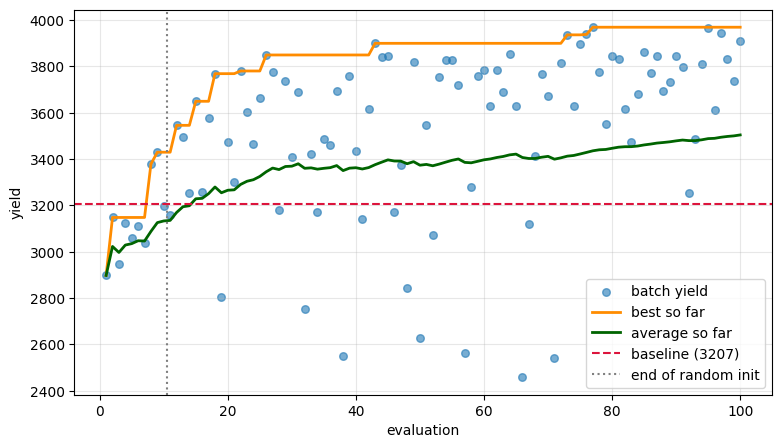

In [17]:
yields = df["yield"].values
best, mean = yields.max(), yields.mean()
print(f"baseline {baseline:.1f}")
print(f"best     {best:.1f}  ({100*(best-baseline)/baseline:+.2f}%)")
print(f"mean     {mean:.1f}  ({100*(mean-baseline)/baseline:+.2f}%)")

plt.figure(figsize=(9, 5))
n = len(yields)
plt.scatter(range(1, n+1), yields, s=30, alpha=.6, label="batch yield")
plt.plot(range(1, n+1), np.maximum.accumulate(yields), color="darkorange", lw=2, label="best so far")
plt.plot(range(1, n+1), np.cumsum(yields)/np.arange(1, n+1), color="darkgreen", lw=2, label="average so far")
plt.axhline(baseline, color="crimson", ls="--", label=f"baseline ({baseline:.0f})")
plt.axvline(n_random + .5, color="grey", ls=":", label="end of random init")
plt.xlabel("evaluation")
plt.ylabel("yield")
plt.legend()
plt.grid(alpha=.3)
plt.show()

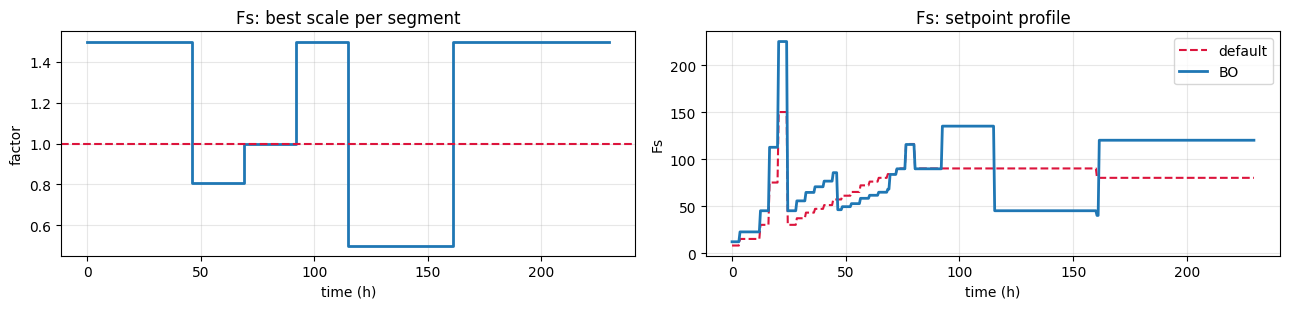

In [18]:
# Best schedule found: factor per segment, and the feed profile it produces.
best_fac = unpack(df.loc[df["yield"].idxmax(), [f"{ch}_s{k}" for ch in SCALED for k in range(N_SEG)]].values)
edges = np.array([0.0] + SEG_EDGES)
grid = np.arange(0, BATCH_HOURS, 0.5)

fig, axes = plt.subplots(len(SCALED), 2, figsize=(13, 3.2*len(SCALED)), squeeze=False)
for i, ch in enumerate(SCALED):
    axes[i][0].step(edges, [best_fac[ch][0]] + best_fac[ch], where="pre", lw=2)
    axes[i][0].axhline(1.0, color="crimson", ls="--")
    axes[i][0].set(title=f"{ch}: best scale per segment", xlabel="time (h)", ylabel="factor",
                   ylim=(LOW - .05, HIGH + .05))

    default = Recipe([dict(sp) for sp in DEFAULTS[ch]], ch)
    tuned = Recipe(piecewise_profile(DEFAULTS[ch], best_fac[ch]), ch)
    axes[i][1].plot(grid, [default.get_value_at(t) for t in grid], color="crimson", ls="--", label="default")
    axes[i][1].plot(grid, [tuned.get_value_at(t) for t in grid], lw=2, label="BO")
    axes[i][1].set(title=f"{ch}: setpoint profile", xlabel="time (h)", ylabel=ch)
    axes[i][1].legend()

for ax in axes.ravel():
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()